# Emissão de CO₂ nas cadeias produtivas brasileiras

## Motivação

![Figura de motivação](apresentacao_exploratoria/motivação.png)


- **Sanguinet, Eduardo Rodrigues; Azzoni, Carlos Roberto (2024).** Carbon emissions drivers in Brazilian regional production chains: Value-added and consumption-based approaches. *Regional Science Policy & Practice*, 16, 100015. [DOI](https://doi.org/10.1016/j.rspp.2024.100015). Fonte dos coeficientes de emissão e referência para a análise das cadeias produtivas.
- **Marques, Alexandra; Rodrigues, João; Lenzen, Manfred; Domingos, Tiago (2012).** Income-based environmental responsibility. *Ecological Economics*, 84, 57–65. [DOI](https://doi.org/10.1016/j.ecolecon.2012.09.010). Referência conceitual para os critérios de atribuição da responsabilidade ambiental.

O notebook utiliza essas referências para uma análise exploratória com a MIP brasileira; não reproduz integralmente os modelos e resultados dos artigos.

## Objetivo

**Calcular as emissões de CO₂ por setor produtivo**.

- Emissões são atibuídas à quem emite;
- Considerando produção nacional para exportação;
- Não consideramos emissões provenientes de importações.

*Fonte dos dados:*
- MIP: 2015, 67 atividades, 127 produtos, IBGE;
- Coeficientes de emissões: Emissões por unidade de produção; Gg CO₂/R$ milhão produzido, Sanguinet e Azzoni 2024.

*Objetos:*

- **Vetores em minúsculas:** um valor por atividade ou produto; interpretados como vetores coluna.
- **Matrizes em maiúsculas:** dois índices, organizados em linhas e colunas.
  $\Phi=\operatorname{diag}(\varphi)$ tem as intensidades na diagonal e zeros fora dela.

| Nome | Símbolo | Dimensão | Significado e Unidade | Fonte |
|---|---|---|---|---|
| Produção bruta | $x$ | 67 × 1 | Produção por atividade; R$ milhões | `'01'!H134:BV134` |
| Inversa de Leontief | $L$ | 67 × 67 | Produção de i por unidade de demanda final de j; adimensional | `'15'!C6:BQ72` |
| Demanda final por prod. | $f$ | 127 × 1 | Demanda por produtos nacionais, incluindo exportações; R$ milhões | `'03'!BZ6:BZ132` |
| Participação setorial | $D$ | 67 × 127 | Linhas: atividades; colunas: produtos; participações adimensionais, cada coluna soma 1 | `'13'!C6:DY72` |
| Demanda final por ativ. | $y$ | 67 × 1 | Demanda por atividade produtora; R$ milhões | $y=Df$ |
| Intens. direta de emissões | $\varphi$ | 67 × 1 | Emissões por unidade de produção; Gg CO₂/R$ milhão produzido | Sanguinet e Azzoni, Tabela 2; interpolação |
| Intensidades na diagonal | $\Phi$ | Diag. × 67 | Intensidades na diagonal; Gg CO₂/R$ milhão produzido | $\Phi=\operatorname{diag}(\varphi)$ |

## Hipóteses e recorte da análise

- **Estrutura econômica:** usamos a MIP nacional do IBGE de **2015**, com 67 atividades e 127 produtos. As emissões são atribuídas às atividades produtoras, incluindo a produção para exportação e excluindo emissões ocorridas no exterior associadas às importações.
- **Coeficientes de emissão:** aproximamos as intensidades de 2015 por interpolação linear dos coeficientes de 2011 e 2018 de Sanguinet e Azzoni: $\varphi_{2015}=\varphi_{2011}+\frac{4}{7}(\varphi_{2018}-\varphi_{2011})$. Assumimos variação linear no período e aplicamos os coeficientes à produção de 2015 sem ajuste adicional de preços. As emissões resultantes são estimativas do cenário, não um inventário observado de 2015.
- **Estimativa para SC:** distribuímos uma parcela da produção brasileira entre as 20 microrregiões históricas por pesos baseados no VAB de 2015 e em hipóteses de especialização setorial, apoiadas em fontes de diferentes anos. Mantemos a intensidade nacional de cada atividade em todas as regiões e preservamos sua participação estadual estimada pela base do VAB.
- **Comparação com o satélite:** comparamos as emissões estimadas de **CO₂, com base econômica em 2015**, à coluna troposférica de **NO₂ observada em 2023** pelo Sentinel-5P/TROPOMI. A comparação descreve padrões espaciais de gases, grandezas e anos diferentes; não constitui validação direta das emissões estimadas.

## Cálculo pela demanda

Multiplicando a matriz diagonal de intensidades temos a matriz de emissões $C$ que relaciona as emissões encadeadas de cada atividade:

$C=\Phi L$ 

$$
C=\Phi L=
\begin{bmatrix}
0{,}0400&0&0&0\\
0&0{,}0500&0&0\\
0&0&0{,}1900&0\\
0&0&0&0{,}0700
\end{bmatrix}
\begin{bmatrix}
1{,}0277&0{,}0544&0{,}0136&0{,}0077\\
0{,}0031&1{,}0406&0{,}0056&0{,}0008\\
0{,}0036&0{,}0091&1{,}0512&0{,}0006\\
0{,}0030&0{,}0045&0{,}0009&1{,}0166
\end{bmatrix}
\approx
\begin{bmatrix}
0{,}0411&0{,}0022&0{,}0005&0{,}0003\\
0{,}0002&0{,}0520&0{,}0003&0{,}0000\\
0{,}0007&0{,}0017&0{,}1997&0{,}0001\\
0{,}0002&0{,}0003&0{,}0001&0{,}0712
\end{bmatrix}.
$$

Ou seja, cada linha de $L$ é multiplicada pelo valor correspondente da diagonal de $Phi$.


Multiplicando C por um vetor de demanda final por atividade $y$, temos um vetor $c$ de emissões por atividade:

$c=Cy$

$$
c=Cy\approx
\begin{bmatrix}
0{,}0411&0{,}0022&0{,}0005&0{,}0003\\
0{,}0002&0{,}0520&0{,}0003&0{,}0000\\
0{,}0007&0{,}0017&0{,}1997&0{,}0001\\
0{,}0002&0{,}0003&0{,}0001&0{,}0712
\end{bmatrix}
\begin{bmatrix}
166\,314{,}6867\\
41\,574{,}2810\\
18\,067{,}2177\\
2\,441{,}7070
\end{bmatrix}
\approx
\begin{bmatrix}
6\,938{,}2168\\
2\,194{,}2086\\
3\,794{,}0654\\
223{,}0284
\end{bmatrix}.
$$

O primeiro elemento é a soma dos produtos da **primeira linha de C**
pelos elementos de y:

$$
c_1=\sum_{j=1}^{4}C_{1j}y_j
=C_{11}y_1+C_{12}y_2+C_{13}y_3+C_{14}y_4.
$$


Dessa forma, podemos calcular as emissões associadas a diferentes níveis e composições da demanda final $y$, incluindo a demanda por uma única atividade ou uma demanda total normalizada.

## Cálculo pela oferta

De forma similar, tendo em vista que $x = Ly$, podemos calcular as emissões para um dado nível de oferta $x$:

$c=Cy=\Phi Ly=\Phi x$

$$
c=\Phi x=
\begin{bmatrix}
0{,}0400&0&0&0\\
0&0{,}0500&0&0\\
0&0&0{,}1900&0\\
0&0&0&0{,}0700
\end{bmatrix}
\begin{bmatrix}
309\,301\\
137\,018\\
32\,411\\
19\,733
\end{bmatrix}
=
\begin{bmatrix}
12\,372{,}0400\\
6\,850{,}9000\\
6\,158{,}0900\\
1\,381{,}3100
\end{bmatrix}.
$$

### Interpretação de $c_i$ pela produção e pela demanda

**Pela produção (oferta):**

$$
c_i=\varphi_i x_i.
$$

$c_i$ representa as emissões da atividade $i$ ao produzir $x_i$, incluindo
a produção destinada a usos intermediários, à demanda final doméstica e às exportações.

**Pela demanda final:**

$$
c_i=\varphi_i\sum_j L_{ij}y_j.
$$

$c_i$ representa as emissões na atividade $i$ necessárias para atender à demanda
final de **todas as atividades**, considerando os encadeamentos diretos e indiretos.
Somamos sobre as colunas $j$, mantendo a atividade emissora $i$.

Como $x_i=\sum_j L_{ij}y_j$, as duas expressões calculam **as mesmas emissões**:

$$
c_i=\varphi_i x_i=\varphi_i\sum_j L_{ij}y_j.
$$

A primeira parte da produção realizada; a segunda explica essa produção pela
demanda final. Em ambas, $i$ identifica **quem emite**, não quem consome.

## 1. Inicializa o notebook


In [1]:
import numpy as np
import pandas as pd
from IPython.display import display
from redes import dados, mip

pd.set_option("display.max_rows", 10)
pd.set_option("display.float_format", "{:,.6f}".format)


## 2. Carrega dados


In [2]:
## Carrega MIP

tabelas = dados.carregar_matriz_67("mip_ibge_2015_67")

L = mip.carregar_inversa_leontief_ibge_67(tabelas)
D = mip.carregar_matriz_participacao_tabela_13_67(tabelas)

atividades = pd.Index(tabelas["01"].iloc[3, 7:74].astype(str).str.split().str[0], name="atividade")
x = pd.Series(tabelas["01"].iloc[133, 7:74].to_numpy(dtype=float), index=atividades)

produtos = pd.Index(tabelas["03"].iloc[5:132, 0].astype(str), name="produto")
f = pd.Series(tabelas["03"].iloc[5:132, 77].to_numpy(dtype=float), index=produtos)

assert x.index.equals(L.index) and x.index.equals(L.columns)
assert D.index.equals(x.index) and D.columns.equals(f.index)
y = D @ f

np.testing.assert_allclose(L @ y, x, rtol=0, atol=1e-6)  # Tolerância: R$ 1.

## Carrega e interpola os coeficientes.
coef_2011 = dados.carregar_coeficientes_co2("sanguinet_azzoni_2011")[2011]
coef_2018 = dados.carregar_coeficientes_co2("sanguinet_azzoni_2018")[2018]
assert coef_2011.index.equals(coef_2018.index)

phi = coef_2011 + (4 / 7) * (coef_2018 - coef_2011)
phi = pd.Series(phi.to_numpy(), index=x.index, name="phi")
assert np.isfinite(phi).all() and (phi >= 0).all()

SHA-256 verificado: Matriz_de_Insumo_Produto_2015_Nivel_67.xls.original
SHA-256 verificado: coeficientes_co2_sanguinet_azzoni_2011.csv
SHA-256 verificado: coeficientes_co2_sanguinet_azzoni_2018.csv


## 4. Calcula as emissões pela oferta e pela demanda

| Nome | Símbolo | Dimensão | Significado e Unidade | Fonte |
|---|---|---|---|---|
| Intensidades na diagonal | $\Phi$ | Diag. × 67 | Intensidades na diagonal; Gg CO₂/R$ milhão produzido | $\Phi=\operatorname{diag}(\varphi)$ |

In [3]:
Phi = pd.DataFrame(
    np.diag(phi),
    index=phi.index,
    columns=phi.index,
)
Phi

atividade,0191,0192,0280,0580,0680,0791,0792,1091,1092,1093,...,7880,8000,8400,8591,8592,8691,8692,9080,9480,9700
atividade,,,,,,,,,,,,,,,,,,,,,
0191,0.034286,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0192,0.000000,0.044286,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0280,0.000000,0.000000,0.178571,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0580,0.000000,0.000000,0.000000,0.075714,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0680,0.000000,0.000000,0.000000,0.000000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8691,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.020000,0.000000,0.000000,0.000000,0.000000
8692,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.028571,0.000000,0.000000,0.000000
9080,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.302857,0.000000,0.000000


| Nome | Símbolo | Dimensão | Significado e Unidade | Fonte |
|---|---|---|---|---|
| Inversa de Leontief | $L$ | 67 × 67 | Produção de i por unidade de demanda final de j; adimensional | `'15'!C6:BQ72` |

In [4]:
L

atividade_destino,0191,0192,0280,0580,0680,0791,0792,1091,1092,1093,...,7880,8000,8400,8591,8592,8691,8692,9080,9480,9700
atividade_origem,,,,,,,,,,,,,,,,,,,,,
0191,1.027732,0.054436,0.013645,0.007712,0.004759,0.004920,0.007342,0.075769,0.553027,0.263244,...,0.002192,0.001848,0.003426,0.004155,0.002084,0.005709,0.004749,0.002088,0.008247,0.000000
0192,0.003118,1.040622,0.005558,0.000849,0.000472,0.000402,0.000710,0.364224,0.004870,0.020241,...,0.000570,0.000186,0.001822,0.002643,0.001097,0.003206,0.002639,0.000536,0.003484,0.000000
0280,0.003578,0.009131,1.051213,0.000648,0.000400,0.000482,0.000641,0.011550,0.002169,0.003985,...,0.000539,0.000132,0.000399,0.000551,0.000384,0.000683,0.000783,0.000437,0.000788,0.000000
0580,0.003023,0.004454,0.000884,1.016587,0.003983,0.000898,0.001486,0.002487,0.002289,0.002917,...,0.000624,0.000117,0.000652,0.000324,0.000296,0.000731,0.000422,0.000523,0.000626,0.000000
0680,0.022982,0.019166,0.010885,0.030039,1.088226,0.032999,0.047653,0.022057,0.029116,0.025308,...,0.004236,0.004645,0.004241,0.002640,0.004184,0.003928,0.003700,0.005477,0.008738,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8691,0.000010,0.000010,0.000003,0.000011,0.000010,0.000076,0.000013,0.000024,0.000019,0.000019,...,0.000005,0.000002,0.000007,0.000004,0.000004,1.000011,0.000996,0.000006,0.000006,0.000000
8692,0.000019,0.000022,0.000011,0.000027,0.000031,0.000033,0.000036,0.000046,0.000036,0.000044,...,0.000053,0.000031,0.000122,0.000034,0.000138,0.000107,1.103236,0.000397,0.000094,0.000000
9080,0.000288,0.000526,0.000295,0.000479,0.000539,0.000440,0.000483,0.001062,0.000537,0.001218,...,0.000733,0.000403,0.001474,0.000520,0.001462,0.000989,0.000426,1.025167,0.010022,0.000000


$C=\Phi L$

In [5]:
C = Phi @ L
C

atividade_destino,0191,0192,0280,0580,0680,0791,0792,1091,1092,1093,...,7880,8000,8400,8591,8592,8691,8692,9080,9480,9700
atividade,,,,,,,,,,,,,,,,,,,,,
0191,0.035237,0.001866,0.000468,0.000264,0.000163,0.000169,0.000252,0.002598,0.018961,0.009026,...,0.000075,0.000063,0.000117,0.000142,0.000071,0.000196,0.000163,0.000072,0.000283,0.000000
0192,0.000138,0.046085,0.000246,0.000038,0.000021,0.000018,0.000031,0.016130,0.000216,0.000896,...,0.000025,0.000008,0.000081,0.000117,0.000049,0.000142,0.000117,0.000024,0.000154,0.000000
0280,0.000639,0.001631,0.187717,0.000116,0.000071,0.000086,0.000114,0.002063,0.000387,0.000712,...,0.000096,0.000023,0.000071,0.000098,0.000069,0.000122,0.000140,0.000078,0.000141,0.000000
0580,0.000229,0.000337,0.000067,0.076970,0.000302,0.000068,0.000113,0.000188,0.000173,0.000221,...,0.000047,0.000009,0.000049,0.000025,0.000022,0.000055,0.000032,0.000040,0.000047,0.000000
0680,0.000230,0.000192,0.000109,0.000300,0.010882,0.000330,0.000477,0.000221,0.000291,0.000253,...,0.000042,0.000046,0.000042,0.000026,0.000042,0.000039,0.000037,0.000055,0.000087,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8691,0.000000,0.000000,0.000000,0.000000,0.000000,0.000002,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.020000,0.000020,0.000000,0.000000,0.000000
8692,0.000001,0.000001,0.000000,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,...,0.000002,0.000001,0.000003,0.000001,0.000004,0.000003,0.031521,0.000011,0.000003,0.000000
9080,0.000087,0.000159,0.000089,0.000145,0.000163,0.000133,0.000146,0.000322,0.000163,0.000369,...,0.000222,0.000122,0.000446,0.000157,0.000443,0.000299,0.000129,0.310479,0.003035,0.000000


| Nome | Símbolo | Dimensão | Significado e Unidade | Fonte |
|---|---|---|---|---|
| Produção bruta | $x$ | 67 × 1 | Produção por atividade; R$ milhões | `'01'!H134:BV134` |

In [6]:
display(x.to_frame(name="Produção bruta"))

,Produção bruta
atividade,
0191,"309,301.000000"
0192,"137,018.000000"
0280,"32,411.000000"
0580,"19,733.000000"
0680,"171,984.000000"
...,...
8691,"179,155.000000"
8692,"222,681.000000"
9080,"34,631.000000"


$c=\Phi x$

In [7]:
c = Phi @ x
display(c.to_frame(name="Emissões de CO₂"))

,Emissões de CO₂
atividade,
0191,"10,604.605714"
0192,"6,067.940000"
0280,"5,787.678571"
0580,"1,494.070000"
0680,"1,719.840000"
...,...
8691,"3,583.100000"
8692,"6,362.314286"
9080,"10,488.245714"


| Nome | Símbolo | Dimensão | Significado e Unidade | Fonte |
|---|---|---|---|---|
| Demanda final por ativ. | $y$ | 67 × 1 | Demanda por atividade produtora; R$ milhões | $y=Df$ |

In [8]:
display(y.to_frame(name="Demanda por atividade"))

,Demanda por atividade
atividade_origem,
0191,"166,314.686749"
0192,"41,574.280991"
0280,"18,067.217657"
0580,"2,441.707034"
0680,"57,860.876177"
...,...
8691,"178,844.471492"
8692,"201,481.223639"
9080,"26,437.870324"


$c=Cy$

In [9]:
display((C@y).to_frame(name="Emissões de CO₂"))

,Emissões de CO₂
atividade,
0191,"10,604.605714"
0192,"6,067.940000"
0280,"5,787.678571"
0580,"1,494.070000"
0680,"1,719.840000"
...,...
8691,"3,583.100000"
8692,"6,362.314286"
9080,"10,488.245714"


In [10]:
# A mesma emissão deve ser recuperada pela demanda final.
np.testing.assert_allclose(c, Phi @ (L @ y), rtol=0, atol=1e-8)
print(f"Emissões pela produção:     {c.sum():,.6f} Gg de CO₂")
print(f"Emissões pela demanda final: {(phi * (L @ y)).sum():,.6f} Gg de CO₂")
print(f"Diferença máxima por atividade: {(c - phi * (L @ y)).abs().max():.2e} Gg de CO₂")

Emissões pela produção:     683,696.041429 Gg de CO₂
Emissões pela demanda final: 683,696.041429 Gg de CO₂
Diferença máxima por atividade: 2.18e-11 Gg de CO₂


## 5. Emissões por demanda final unitária: heatmap de C

$$C=\Phi L,\qquad C_{ij}=\varphi_iL_{ij}.$$

- **Linha i:** atividade que emite. **Coluna j:** atividade que recebe a demanda final.
- **$C_{ij}$:** emissões em i para atender a **R$ 1 milhão de demanda final de j**,
  considerando a cadeia nacional direta e indireta. Unidade: Gg CO₂/R$ milhão de demanda final.
- **$C_{ii}=\varphi_iL_{ii}$:** emissões na própria atividade i para atender à sua
  demanda final unitária. Inclui a produção final e os retornos da cadeia a i;
  portanto, não é apenas a intensidade direta $\varphi_i$.
- **Soma da coluna j**, $\sum_i C_{ij}$: emissões em todas as atividades da cadeia
  para atender a R$ 1 milhão de demanda final de j.
- **Soma da linha i**, $\sum_j C_{ij}$: a soma indica as emissões na atividade i, em Gg de CO₂.
num cenário cenário de **R$ 1 milhão de demanda final em cada uma das 67 atividades** (R$ 67 milhões no total),
o que não reflete um cenário tecnologico razoável.

Os eixos usam nomes abreviados das atividades do IBGE; os códigos permanecem nos dados. A paleta **viridis invertida** usa tons
claros para menos emissões e escuros para mais emissões, em escala logarítmica.
Zeros não entram no logaritmo e recebem a cor mais clara, assim como o menor valor
positivo. A diagonal é preservada. O gráfico não pondera pela demanda observada
e não altera os valores da matriz.

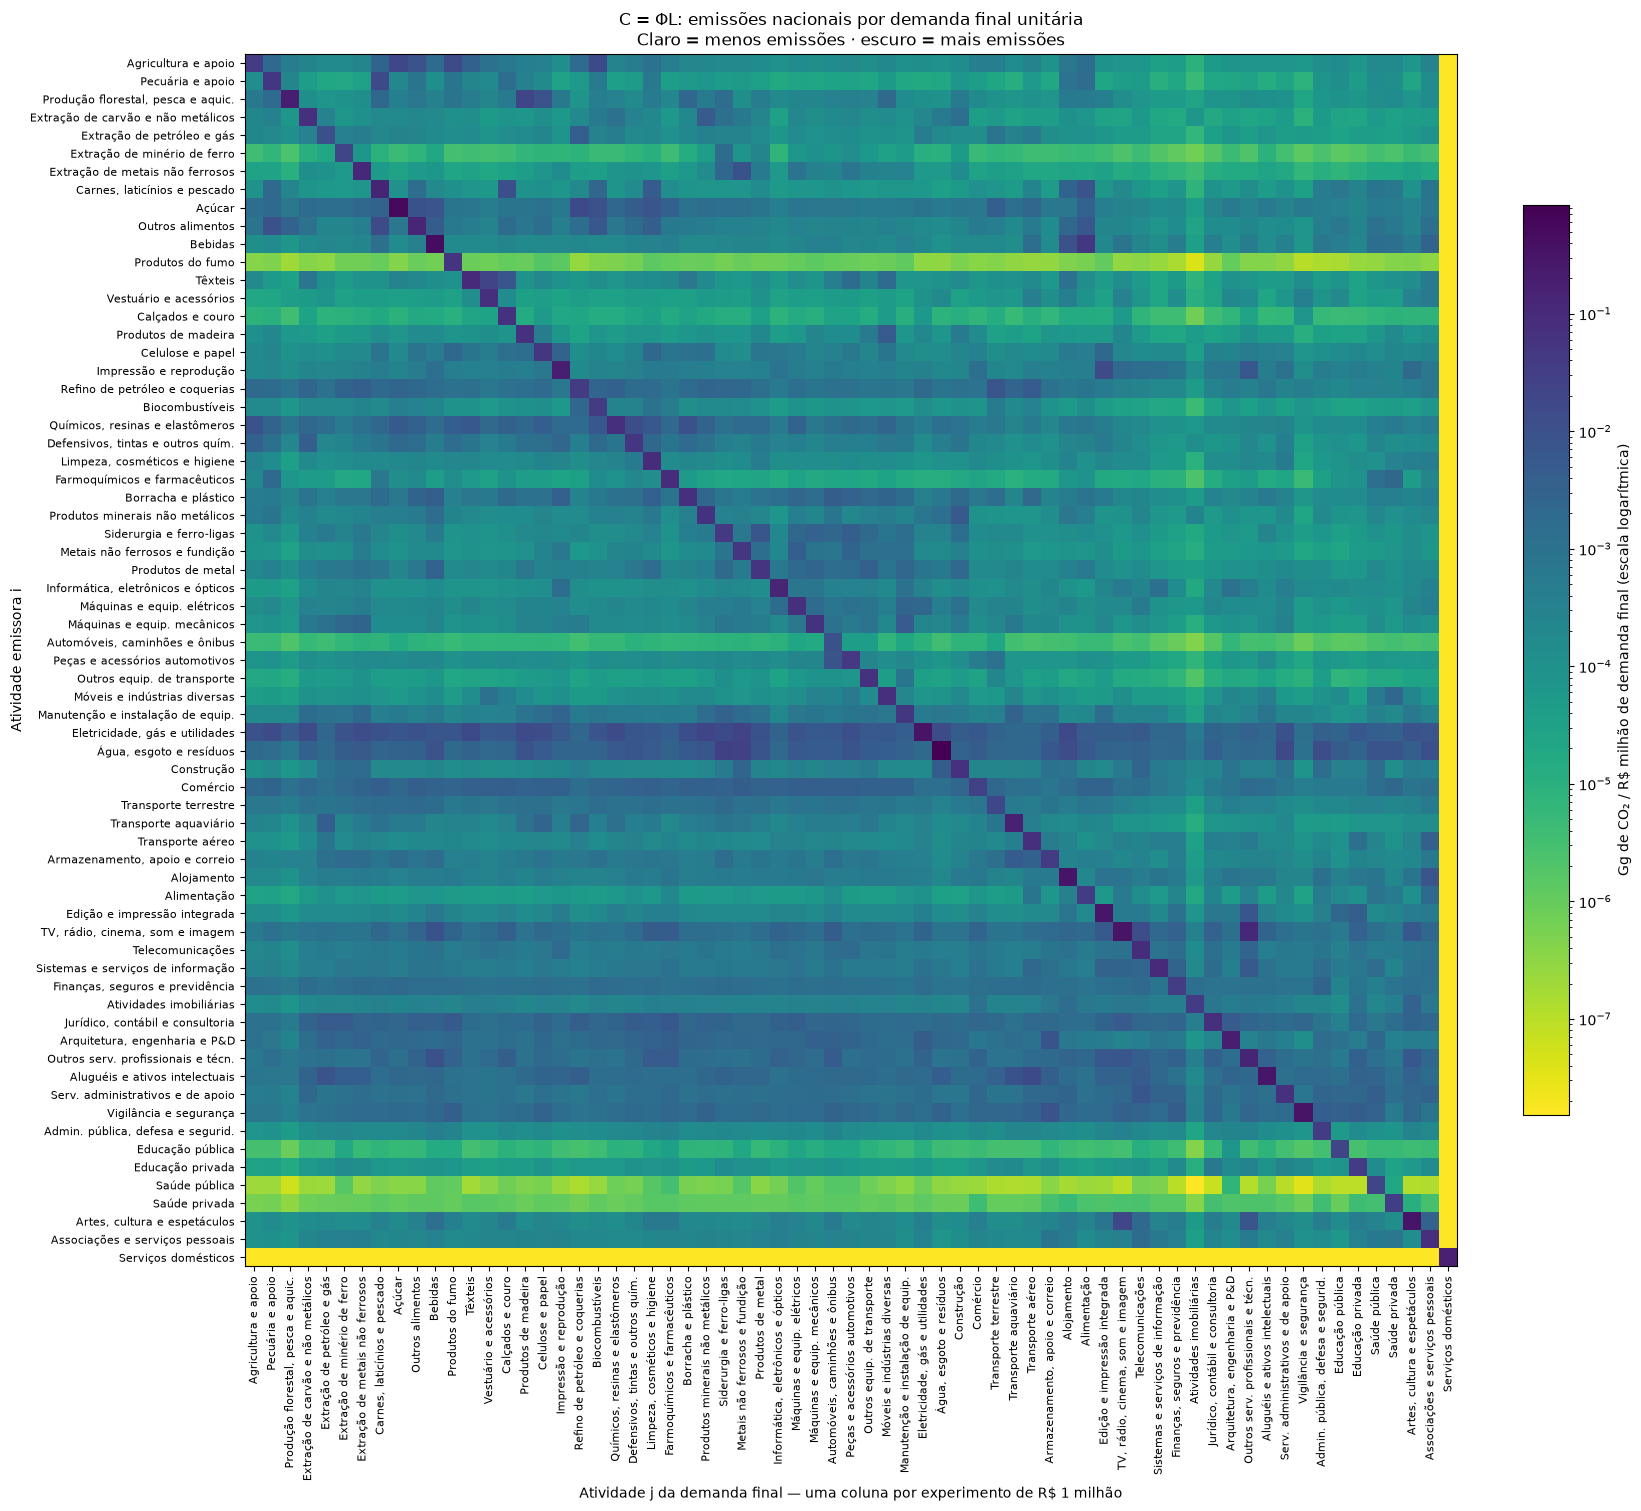

In [11]:
from redes.visualizacoes import mostrar_heatmap_emissoes, mostrar_emissoes_vab

mostrar_heatmap_emissoes(C)

## 6. Emissões por atividade e valor adicionado bruto (VAB)

Podemos relacionar as emissões de cada atividade à sua participação na economia, representada pelo valor adicionado bruto. Calculamos o VAB subtraindo o consumo intermediário da produção:

$$vab_i=x_i-ci_i.$$

| Nome | Símbolo | Dimensão | Significado e Unidade | Fonte |
|---|---|---|---|---|
| Consumo intermediário | $ci$ | 67 × 1 | Insumos consumidos por atividade, a preços de consumidor; R$ milhões | `'02'!C134:BQ134` |
| Valor adicionado bruto | $vab$ | 67 × 1 | Valor adicionado por atividade; R$ milhões | $vab=x-ci$ |

In [13]:
# Aba 02, C134:BQ134: consumo intermediário total por atividade.
atividades_ci = pd.Index(tabelas["02"].iloc[3, 2:69].astype(str).str.split().str[0])
assert atividades_ci.equals(x.index)
ci = pd.Series(tabelas["02"].iloc[133, 2:69].to_numpy(dtype=float), index=x.index)
vab = (x - ci).rename("VAB (R$ milhões)")
display(vab.to_frame())

,VAB (R$ milhões)
atividade,
0191,"163,127.000000"
0192,"71,449.000000"
0280,"24,391.000000"
0580,"8,855.000000"
0680,"73,556.000000"
...,...
8691,"119,144.000000"
8692,"133,287.000000"
9080,"19,139.000000"


### Interpretação dos três painéis

Usamos as emissões $c=\Phi x=Cy$, calculadas para a produção observada, incluindo exportações. As atividades aparecem na mesma ordem nos três painéis, da maior para a menor emissão.

1. **Emissões por atividade:** $c_i$, em Gg de CO₂.
2. **Emissões em relação ao VAB:** razão entre a participação da atividade nas emissões e sua participação no VAB:

$$\frac{c_i/\sum_j c_j}{vab_i/\sum_j vab_j}.$$

Um valor maior que 1 indica que a participação nas emissões supera a participação no VAB. Um valor menor que 1 indica o inverso. A razão é adimensional.

3. **Participação no VAB:** $100\,vab_i/\sum_j vab_j$, em porcentagem.

Em todos os casos, $i$ identifica a atividade emissora. Pela produção, $c_i$ corresponde às emissões para produzir $x_i$; pela demanda, às emissões nessa mesma atividade para atender à demanda final de toda a economia:

$$c_i=\varphi_i x_i=\varphi_i\sum_j L_{ij}y_j.$$

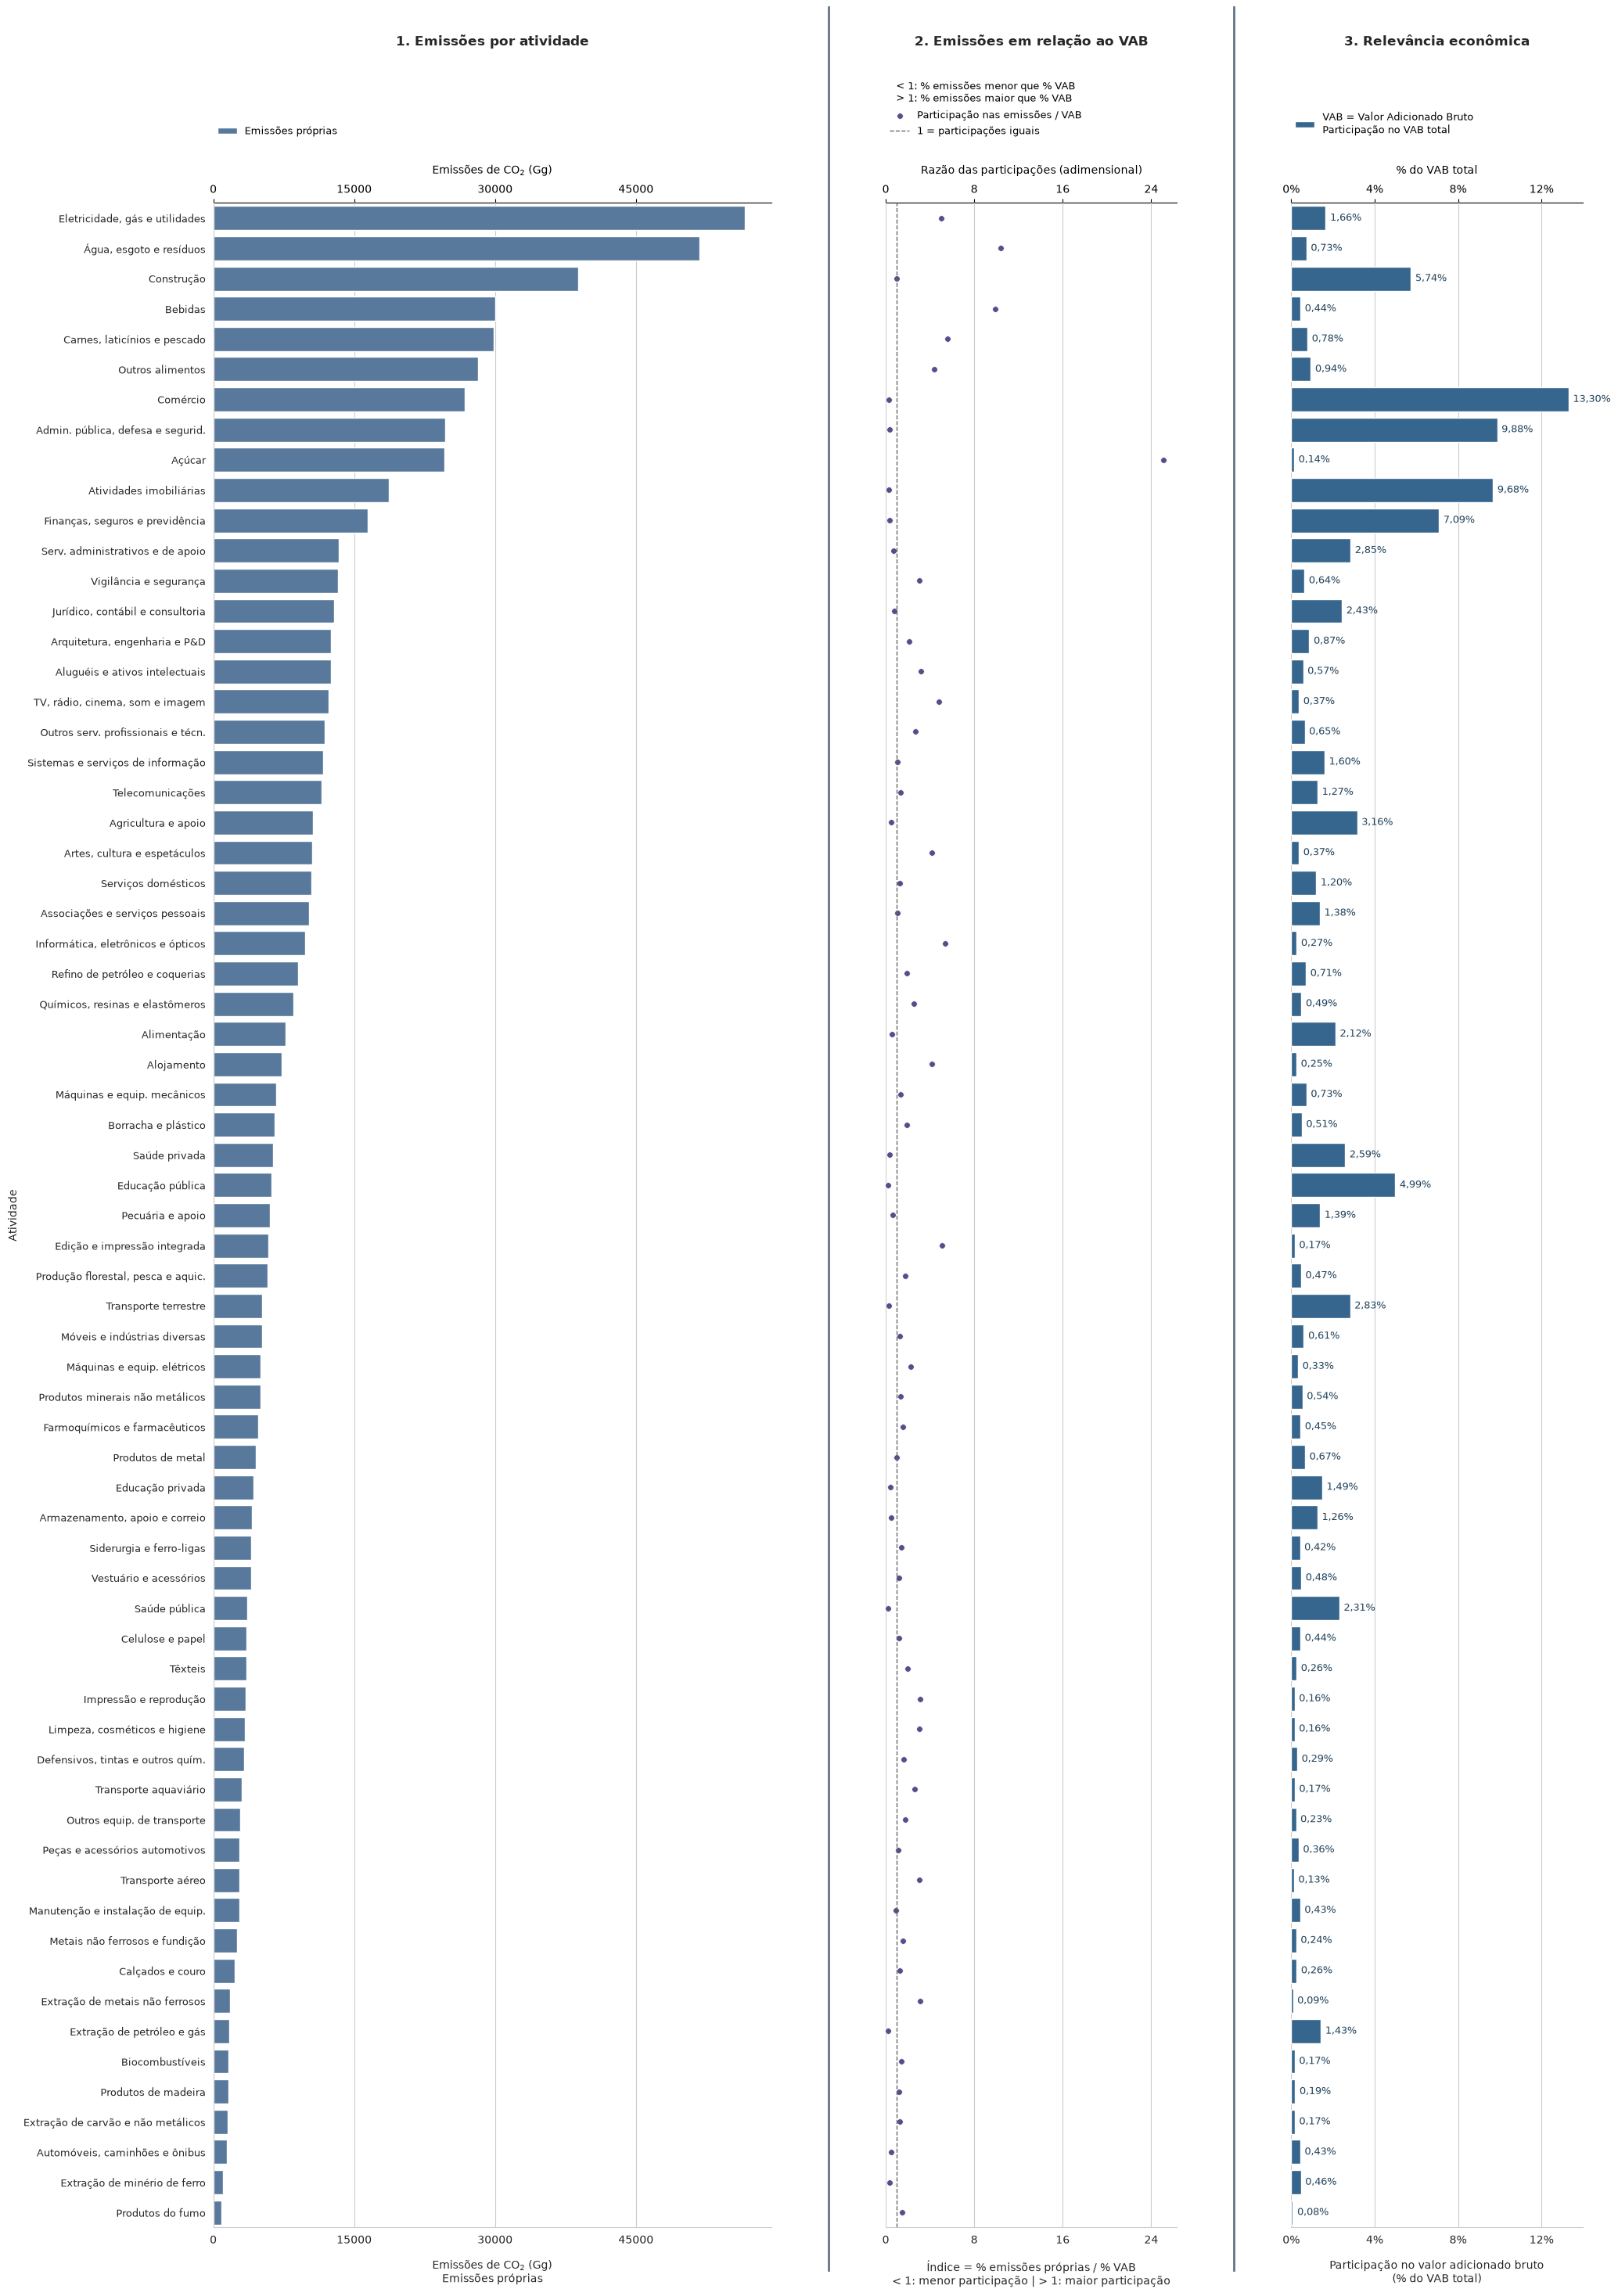

In [14]:
mostrar_emissoes_vab(c, vab)

## 7. Emissões nas microrregiões de Santa Catarina

Distribuímos uma parcela das emissões brasileiras entre as **20 microrregiões históricas de Santa Catarina** por meio da matriz de pesos $W$, que relaciona as 67 atividades às microrregiões.

Os pesos de $W$ foram estimados a partir da participação de cada microrregião no VAB brasileiro de 2015, por quatro grupos econômicos (IBGE/SIDRA, tabela 5938), e ajustados por fatores de especialização setorial definidos com base em informações sobre a economia regional. Esses fatores são hipóteses, não medidas observadas de produção setorial.

O ajuste redistribui a participação de cada atividade entre as microrregiões, preservando seu total estadual estimado pela base VAB. As informações de especialização são de diferentes anos; a produção e o VAB têm referência em 2015.
- **Linha $i$:** atividade produtiva.
- **Coluna $r$:** microrregião.
- **$W_{ir}$:** fração da produção brasileira da atividade $i$ atribuída à região $r$; peso estimado, não produção regional observada.

A partir de $W$, calculamos $q_i=\sum_r W_{ir}$, a participação estimada de SC na produção brasileira da atividade $i$. Em seguida, normalizamos cada linha de $W$ por $q_i$, obtendo $S_{ir}=W_{ir}/q_i$, a participação de cada microrregião na produção estadual daquela atividade. Assim, cada linha de $S$ soma 1.

$$S_{ir}=\frac{W_{ir}}{q_i},\qquad \sum_r S_{ir}=1.$$


| Nome | Símbolo | Dimensão | Significado e Unidade | Fonte |
|---|---|---|---|---|
| Pesos regionais | $W$ | 67 × 20 | Participação da microrregião na produção brasileira de cada atividade; adimensional | `pesos_setores_microrregioes_2015.csv`, campo `peso_micro_brasil` |
| Participação estadual | $q$ | 67 × 1 | Participação estimada de SC na produção brasileira de cada atividade; adimensional | $q_i=\sum_r W_{ir}$ |
| Distribuição dentro de SC | $S$ | 67 × 20 | Participação da microrregião na produção estadual de cada atividade; adimensional | $S_{ir}=W_{ir}/q_i$ |


O heatmap mostra $100S_{ir}$, em porcentagem. Por exemplo, o valor 20 indica que a microrregião recebe 20% da produção estimada daquele setor **em SC**. Cada linha soma 100%; valores positivos menores que 0,05% aparecem como 0,0.

*Fonte dos pesos:* IBGE/SIDRA, tabela 5938, e hipóteses descritas em [fatores_setoriais_estimados.csv](microrregioes_sc/dados/fatores_setoriais_estimados.csv). O procedimento está documentado no [README da regionalização](microrregioes_sc/README.md).

SHA-256 verificado: pesos_setores_microrregioes_2015.csv
SHA-256 verificado: microrregioes_sc_terra.geojson


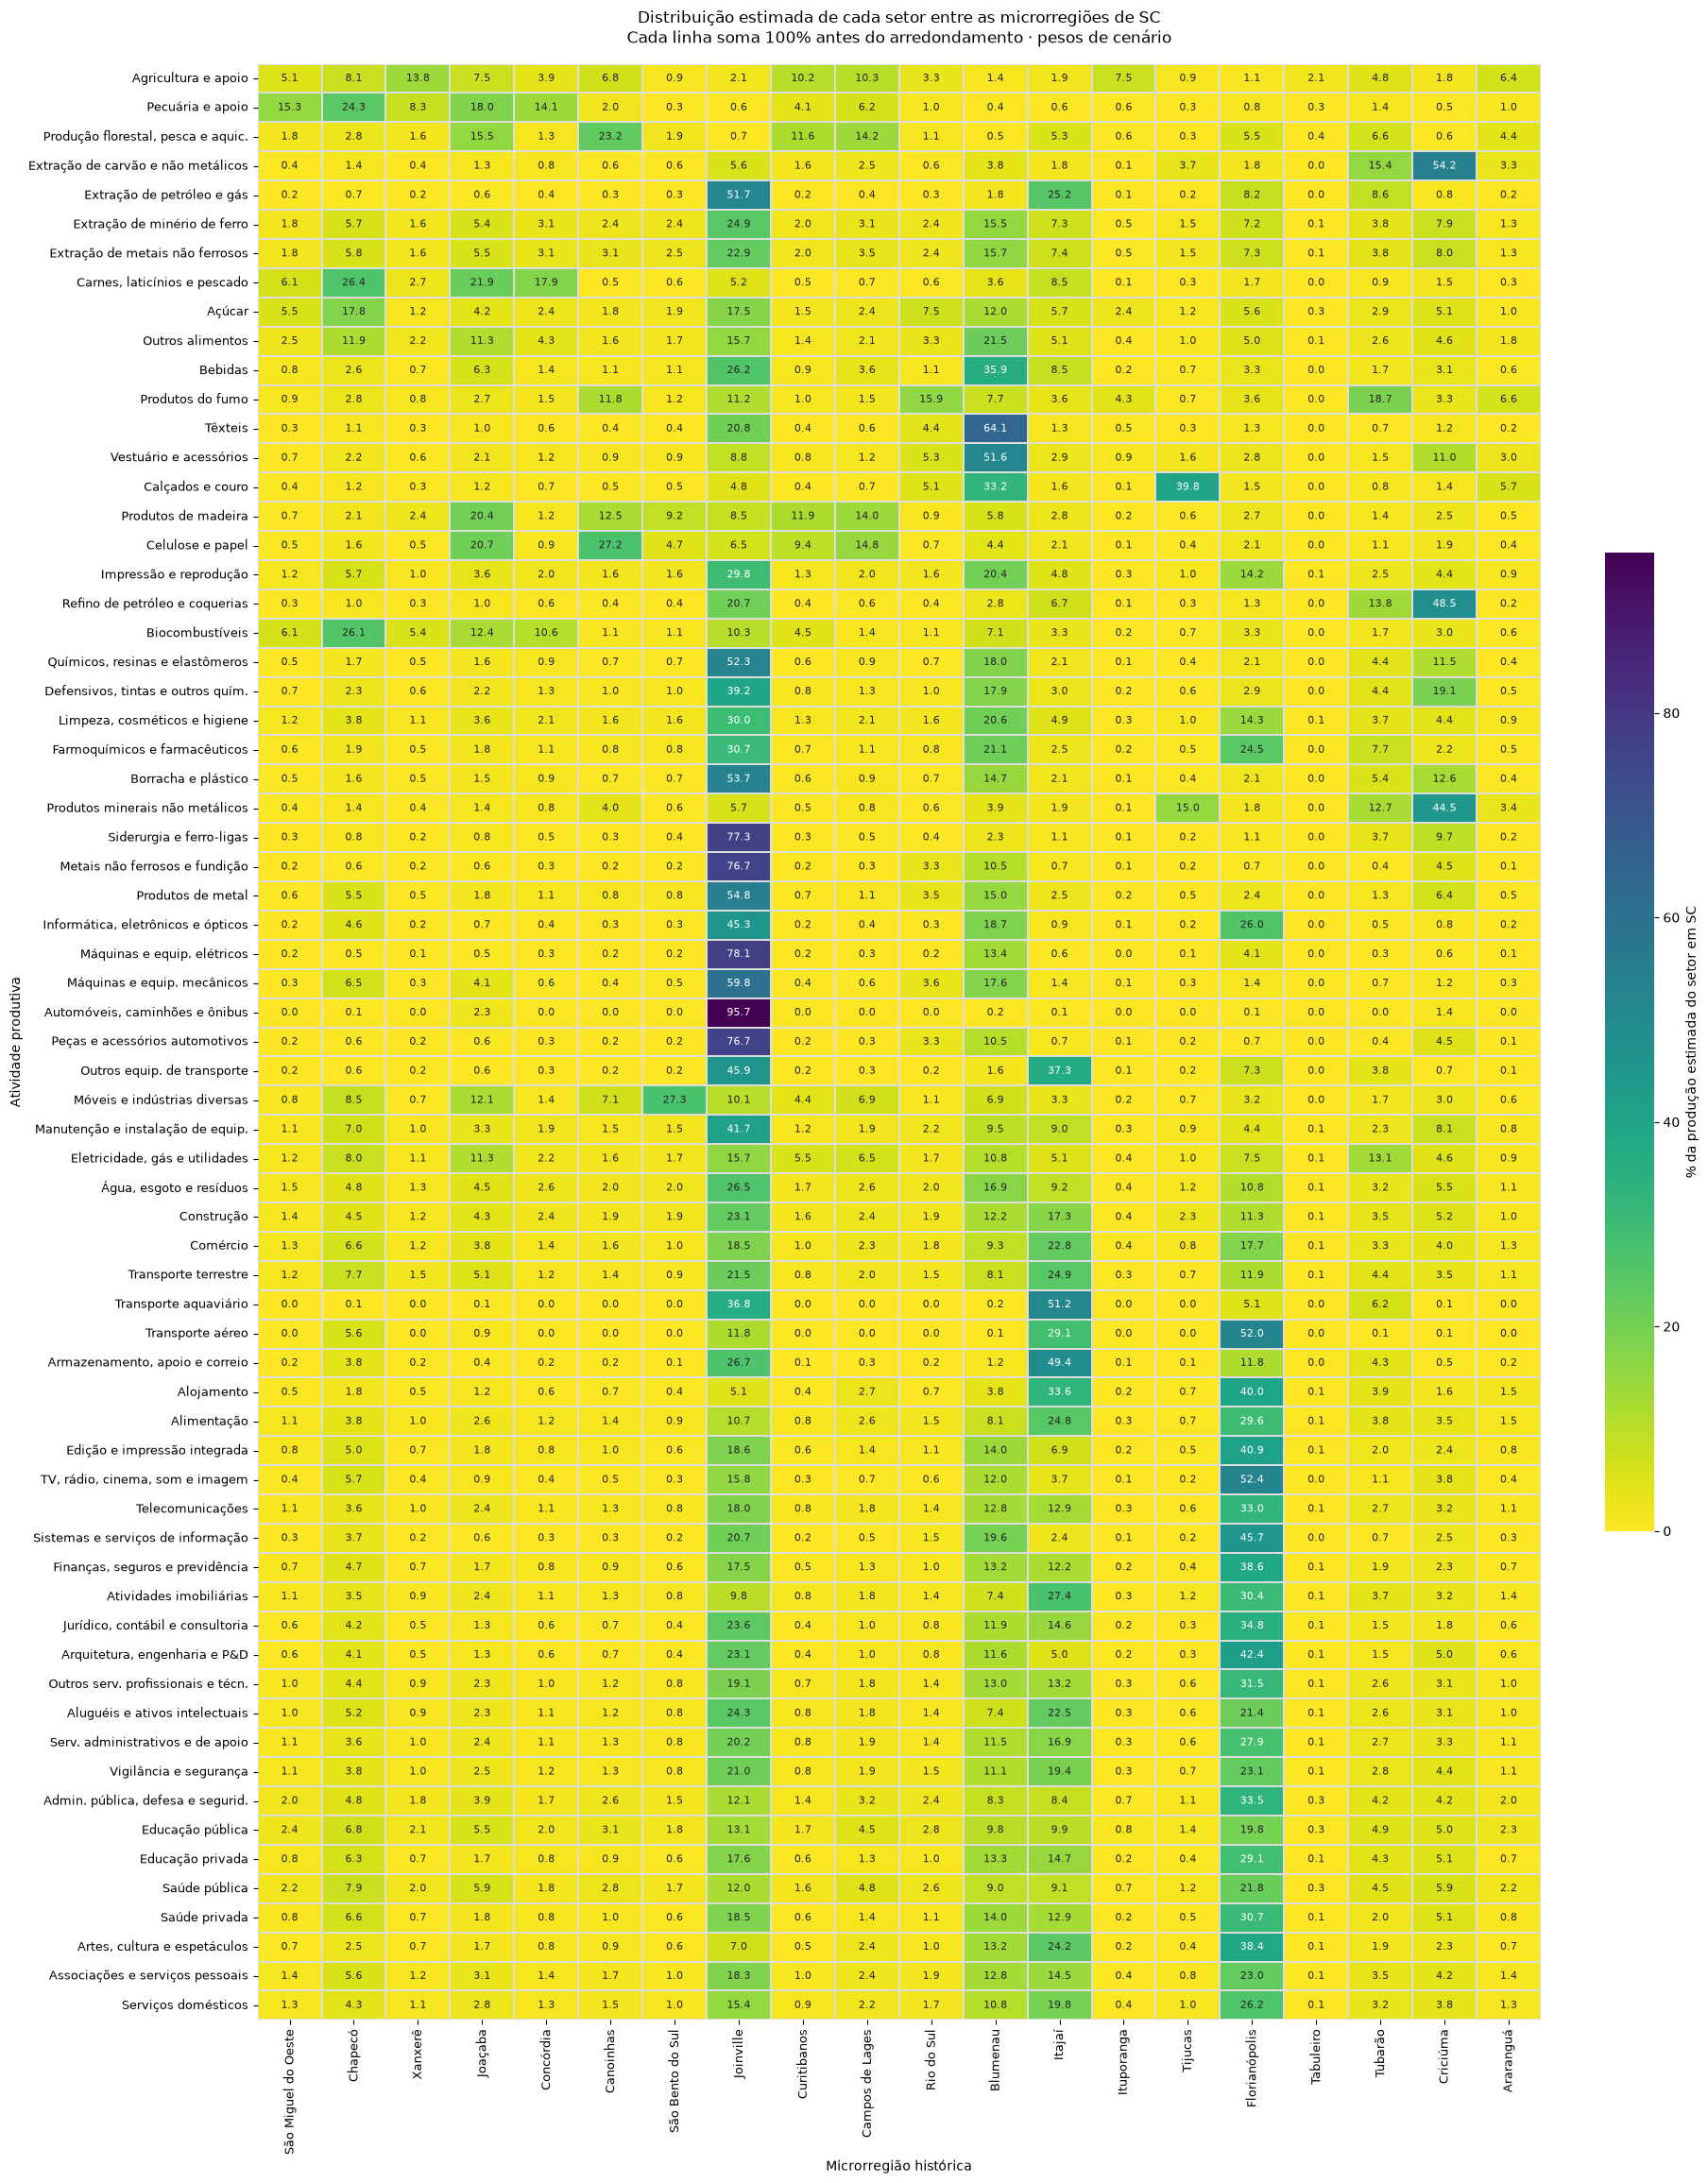

In [15]:
import json
from redes.visualizacoes import mostrar_pesos_microrregioes, mostrar_mapa_microrregioes

pasta_sc = dados.RAIZ_PROJETO / "microrregioes_sc" / "dados"
entradas_sc = pd.read_csv(pasta_sc / "entradas.csv").set_index("categoria")
for categoria in ["pesos_microregioes", "terra"]:
    entrada_sc = entradas_sc.loc[categoria]
    dados.check_sha256(pasta_sc.parent / entrada_sc["arquivo"], entrada_sc["sha256"])

pesos_sc = pd.read_csv(pasta_sc / "pesos_setores_microrregioes_2015.csv",
                       dtype={"atividade": str, "codigo_ibge": str})
regioes_sc = json.loads((pasta_sc / "microrregioes_sc_terra.geojson").read_text(encoding="utf-8"))["features"]
nomes_micro = pesos_sc[["codigo_ibge", "microrregiao"]].drop_duplicates().set_index("codigo_ibge")["microrregiao"]
W = pesos_sc.pivot(index="atividade", columns="codigo_ibge", values="peso_micro_brasil")
assert set(W.index) == set(x.index)
assert set(W.columns) == {r["properties"]["codigo_ibge"] for r in regioes_sc}
W = W.reindex(index=x.index, columns=sorted(W.columns))
assert W.shape == (67, 20) and np.isfinite(W.to_numpy()).all() and (W >= 0).all().all()

q = W.sum(axis=1)
assert (q > 0).all() and (q <= 1).all()
S = W.div(q, axis="index")
# Confere a distribuição com a coluna já publicada no arquivo de pesos.
S_arquivo = pesos_sc.pivot(index="atividade", columns="codigo_ibge", values="peso_micro_sc")
np.testing.assert_allclose(S, S_arquivo.reindex(index=W.index, columns=W.columns), rtol=0, atol=1e-8)
mostrar_pesos_microrregioes(S.rename(columns=nomes_micro))

### Cálculo das emissões regionais

Multiplicando os pesos pela produção brasileira $x$, temos a produção atribuída a cada microrregião. Aplicando a intensidade nacional $\varphi_i$, obtemos suas emissões:

$$X^{SC}_{ir}=W_{ir}x_i,\qquad E^{SC}_{ir}=\varphi_iX^{SC}_{ir}=W_{ir}c_i.$$

- **$X^{SC}$:** matriz 67 × 20 de produção, em R$ milhões.
- **$E^{SC}$:** matriz 67 × 20 de emissões, em Gg de CO₂.
- **Linhas:** atividades. **Colunas:** microrregiões.

Somando as atividades de cada coluna, temos o vetor $e^{SC}$, com 20 × 1 valores de emissões regionais:

$$e^{SC}_r=\sum_i E^{SC}_{ir},\qquad e^{SC}=W^{\mathsf T}c.$$

Assim, $e^{SC}_r$ representa as emissões estimadas na microrregião $r$ para realizar a produção que lhe foi atribuída, incluindo a produção para exportação. Mantemos a mesma intensidade nacional por atividade em todas as regiões.

Como $W$ expressa participações na produção brasileira, a soma regional recupera a parcela estimada para SC:

$$\sum_r e^{SC}_r=\sum_i q_i c_i.$$

O vetor $c$ já contém as emissões da produção nacional; esta etapa apenas as distribui espacialmente. O resultado depende dos pesos de produção e da hipótese de intensidade uniforme por setor, sem distinguir tecnologias locais.

Emissões estimadas em SC: 31,241.41 Gg de CO₂
Participação no total brasileiro do cenário: 4.57%


,Emissões estimadas (Gg CO₂)
codigo_ibge,
Joinville,"6,771.771619"
Florianópolis,"4,645.996897"
Blumenau,"4,158.412682"
Itajaí,"3,233.042530"
Chapecó,"2,112.498940"
...,...
Xanxerê,426.417914
Tijucas,347.087084
Araranguá,341.408192


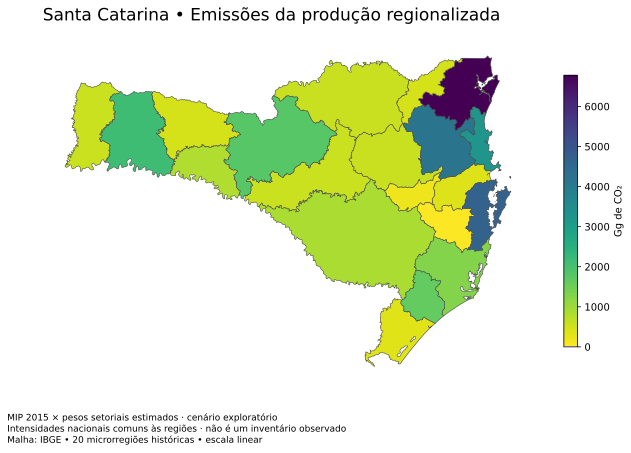

In [15]:
X_sc = W.mul(x, axis="index")
E_sc = X_sc.mul(phi, axis="index")
e_sc = E_sc.sum(axis=0).rename("Emissões estimadas (Gg CO₂)")

np.testing.assert_allclose(E_sc, W.mul(c, axis="index"), rtol=0, atol=1e-8)
np.testing.assert_allclose(e_sc, W.T @ c, rtol=0, atol=1e-8)
np.testing.assert_allclose(e_sc.sum(), q @ c, rtol=0, atol=1e-8)
print(f"Emissões estimadas em SC: {e_sc.sum():,.2f} Gg de CO₂")
print(f"Participação no total brasileiro do cenário: {100 * e_sc.sum() / c.sum():.2f}%")
display(e_sc.rename(index=nomes_micro).sort_values(ascending=False).to_frame())

mostrar_mapa_microrregioes(e_sc, regioes_sc)

## 8. Comparação com o mapa de satélite

Podemos comparar a distribuição das emissões estimadas com o padrão espacial de NO₂ observado por satélite:

- **À esquerda:** emissões de CO₂ atribuídas às microrregiões, com base na produção de 2015.
- **À direita:** coluna troposférica de NO₂ observada em 2023, em $10^{15}$ moléculas/cm².

Os dados de satélite são do **Sentinel-5P/TROPOMI (Copernicus)**, processados pelo **FMI/SAMPO** em uma composição anual com células de 0,05° × 0,05°. O processamento aplica o filtro de qualidade `qa_value > 0,75` e agrega as observações em composições mensais e anual.

Usamos as células válidas, com peso HARP positivo, e recortamos o mapa à área terrestre de SC, definida pelos limites do IBGE e pela máscara GSHHG.

Tons claros indicam valores menores e tons escuros, valores maiores. Cada painel tem sua própria escala. A comparação é espacial: as grandezas representam gases e anos diferentes, e a coluna de NO₂ expressa a quantidade na troposfera por unidade de área, não as emissões ou a concentração ao nível do solo.

*Fonte dos dados:* [FMI/SAMPO](https://sampo.fmi.fi/tropomi_l3/info_dev.php). Os dados de aquisição e processamento estão registrados em [no2_fmi_2023_fontes.json](microrregioes_sc/dados/no2_fmi_2023_fontes.json).

SHA-256 verificado: no2_fmi_2023_sc.npz


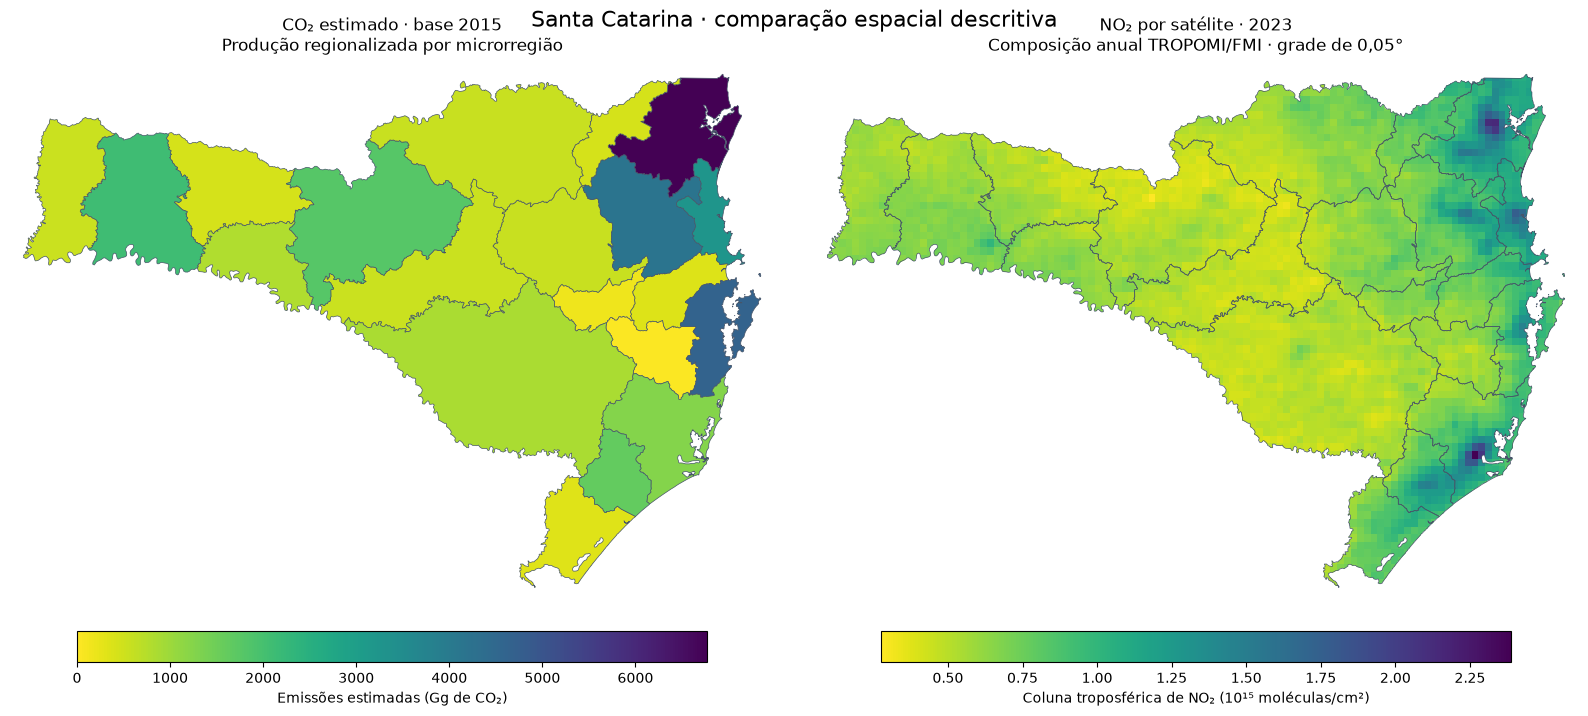

In [16]:
from redes.visualizacoes import mostrar_comparacao_satelite

entrada_satelite = entradas_sc.loc["satelite"]
arquivo_satelite = pasta_sc.parent / entrada_satelite["arquivo"]
dados.check_sha256(arquivo_satelite, entrada_satelite["sha256"])
with np.load(arquivo_satelite) as arquivo:
    grade_no2 = {nome: arquivo[nome] for nome in arquivo.files}

mostrar_comparacao_satelite(e_sc, regioes_sc, grade_no2)

**Fontes:** [IBGE — MIP 2015](https://www.ibge.gov.br/estatisticas/economicas/contas-nacionais/9085-matriz-de-insumo-produto.html);
[Sanguinet e Azzoni (2024), equações 1 e 3a, p. 2, e Tabela 2](references/sanguinet_azzoni_2024/carbon_emissions_drivers_brazilian_regional_production_chains.pdf).